In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LinearRegression, Lasso 
from sklearn.datasets import make_regression 
from sklearn.model_selection import train_test_split

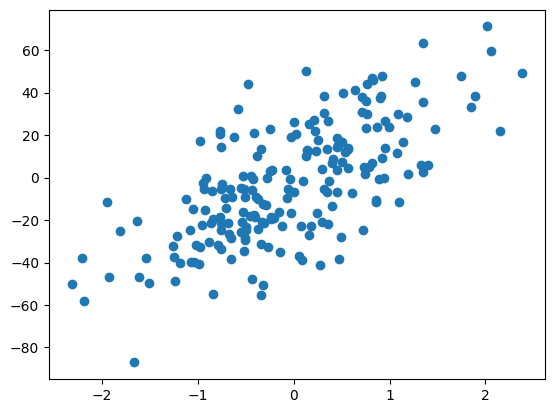

In [4]:
X,y = make_regression(n_samples=200, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

In [5]:
lr = LinearRegression()
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[22.30644252]
-1.8292976015061677


C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\base.py:1363: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.223e+04, tolerance: 1.249e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_

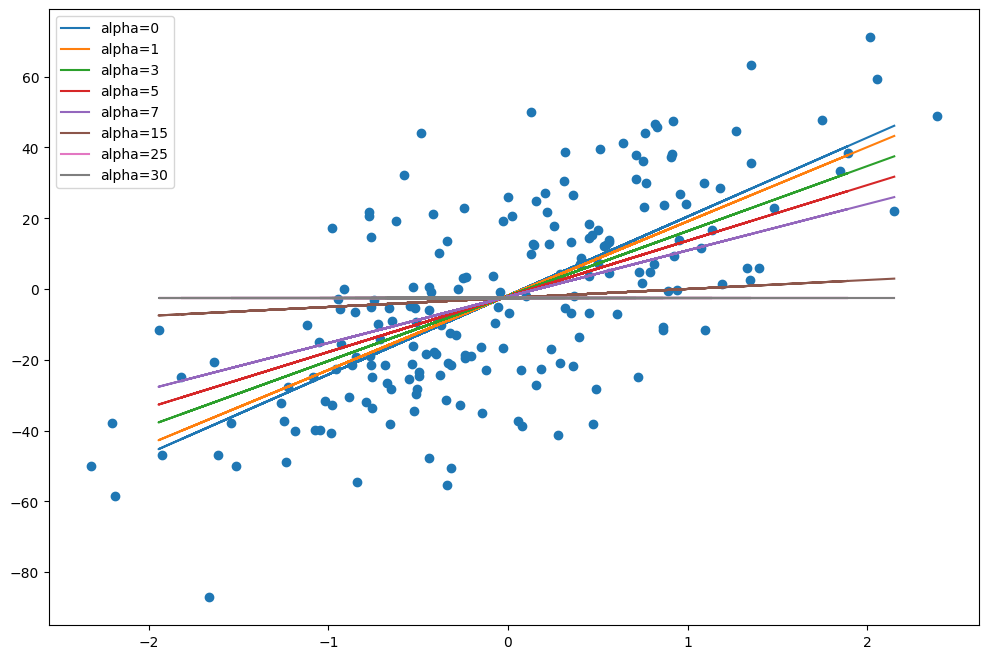

In [7]:
alphas = [0,1,3,5,7,15,25,30]
plt.figure(figsize=(12,8)) 
plt.scatter(X,y)  

for i in alphas: 
    lo = Lasso(alpha=i)
    lo.fit(X_train,y_train) 
    plt.plot(X_test,lo.predict(X_test),label = f'alpha={i}')

plt.legend()

# For Polynomial Data 

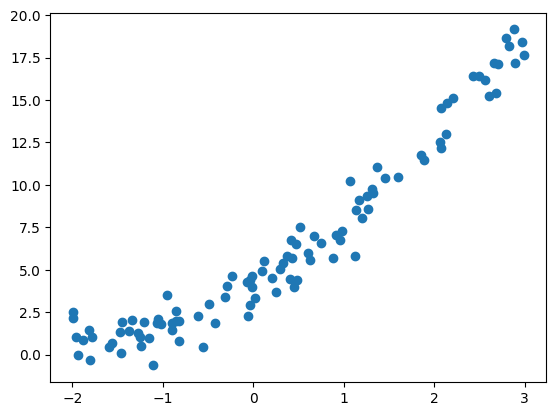

In [8]:
x1= 5*np.random.rand(100,1) - 2 
y1 = 0.7*x1**2 + 3*x1 + 4 + np.random.randn(100,1) 

plt.scatter(x1,y1)

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\base.py:1363: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.197e+01, tolerance: 3.040e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_

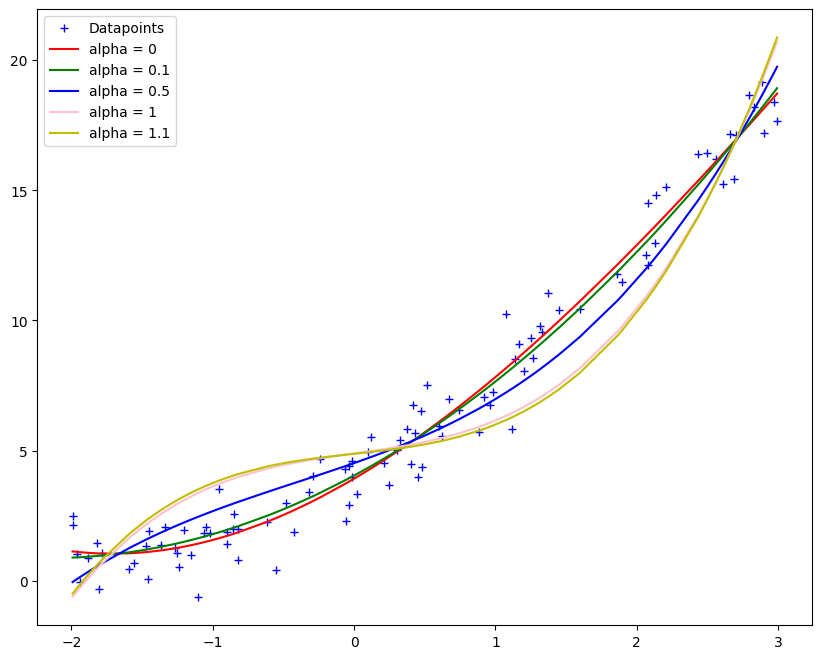

In [14]:
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import PolynomialFeatures 


def lasso_pred(x1, x2, alpha): 
    model = Pipeline([
        ('poly_features',PolynomialFeatures(degree = 3)),
        ('lasso', Lasso(alpha = alpha)) 
    ])
    model.fit(x1,y1) 
    return model.predict(x1) 
alphas = [0,0.1,0.5,1,1.1] 
colors = ['r','g','b','pink','y'] 

plt.figure(figsize=(10,8)) 
plt.plot(x1, y1, "b+",label = 'Datapoints')

for alpha, c in zip(alphas,colors): 
    pred = lasso_pred(x1,y1,alpha) 
    plt.plot(sorted(x1[:,0]), pred[np.argsort(x1[:,0])], c, label =f'alpha = {alpha}')

plt.legend()